# Q1 PHE-ICH Prior Transfer Pipeline

Notebook này triển khai khung trong `research.md` theo hướng:

- **Target**: PHE-SICH-CT-IDS, ưu tiên `SubdatasetA_NIFIT/NIFIT` cho phân vùng PHE.
- **Source ICH**: Seg-CQ500 và INSTANCE 2022 nếu có sẵn; PhysioNet CT-ICH để dạng optional vì cần DUA.
- **Mô hình chính**: teacher-student, học hemorrhage prior từ source ICH rồi distill sang PHE.
- **Không đi lệch trục**: không dùng RSNA/BHSD, không pseudo-IPH từ edema mask, không biến bài thành thử backbone đơn thuần.
- **Đánh giá**: patient-level/volume-level, low-label 10/25/50/100%, calibration, uncertainty và volume reliability.

Mặc định notebook chỉ chạy audit, manifest, split và smoke-test nhẹ. Các cell train nặng được điều khiển bằng `RUN_HEAVY_TRAINING`.


## 1. Mapping từ plan sang notebook

| Plan trong `research.md` | Cell tương ứng |
|---|---|
| Dữ liệu public-only, reproducible | Audit path, build manifest, ghi license/source notes |
| PHE-SICH làm target | `build_phe_manifest`, patient-level folds, low-label subsets |
| Seg-CQ500 + INSTANCE + PhysioNet làm source ICH | `build_seg_cq500_manifest`, `build_instance_manifest`, `build_physionet_manifest` |
| 2D và 2.5D physical-depth-aware | CT windowing, `physical_neighbor_indices`, `make_25d_stack` |
| Teacher-student hemorrhage prior transfer | Source teacher, target student, prior distillation loss |
| Low-label fine-tuning | 10/25/50/100% train subsets theo volume strata |
| Uncertainty + volume reliability | log-variance head, calibration metrics, volume metrics, bootstrap CI |
| Ablation Q1 | Experiment matrix và ablation registry |


In [1]:
from pathlib import Path
from dataclasses import dataclass, asdict


@dataclass
class ExperimentConfig:
    project_root: Path = Path.cwd()
    seed: int = 42
    image_size: int = 384
    smoke_image_size: int = 256
    n_folds: int = 5
    outer_fold: int = 0
    val_fraction: float = 0.125
    label_fractions: tuple = (0.10, 0.25, 0.50, 1.00)
    windows: tuple = (
        ("brain", -20.0, 100.0),
        ("blood", -50.0, 150.0),
        ("wide", 0.0, 600.0),
    )
    physical_offsets_mm: tuple = (-6.0, -3.0, 0.0, 3.0, 6.0)
    run_heavy_training: bool = False
    run_smoke_test: bool = True
    max_smoke_subjects: int = 2


CFG = ExperimentConfig()
PROJECT_ROOT = CFG.project_root.resolve()

PHE_ROOT = PROJECT_ROOT / "PHE-SICH-CT-IDS" / "SubdatasetA_NIFIT" / "NIFIT"
PHE_IMAGE_DIR = PHE_ROOT / "set"
PHE_MASK_DIR = PHE_ROOT / "label"

SEG_CQ500_ROOT = PROJECT_ROOT / "Seg-CQ500" / "Seg-CQ500" / "data" / "volumes"
INSTANCE_ROOT = PROJECT_ROOT / "Instance2022" / "train_2"
PHYSIONET_ROOT = PROJECT_ROOT / "PhysioNet_CT_ICH"  # optional, restricted access

OUTPUT_ROOT = PROJECT_ROOT / "outputs_q1_prior_transfer"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
PRIOR_DIR = OUTPUT_ROOT / "teacher_priors"
LOG_DIR = OUTPUT_ROOT / "logs"

for path in [OUTPUT_ROOT, MANIFEST_DIR, FIG_DIR, TABLE_DIR, CHECKPOINT_DIR, PRIOR_DIR, LOG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output root :", OUTPUT_ROOT)
print("Heavy training:", CFG.run_heavy_training)


Project root: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao
Output root : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_q1_prior_transfer
Heavy training: False


In [2]:
import os
import json
import math
import random
import time
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    import nibabel as nib
    NIB_AVAILABLE = True
except Exception as exc:
    nib = None
    NIB_AVAILABLE = False
    print("nibabel is not available:", exc)

try:
    from scipy import ndimage
    from scipy.stats import pearsonr, spearmanr, wilcoxon
    SCIPY_AVAILABLE = True
except Exception as exc:
    ndimage = None
    pearsonr = spearmanr = wilcoxon = None
    SCIPY_AVAILABLE = False
    print("scipy is not available:", exc)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception as exc:
    torch = nn = F = Dataset = DataLoader = None
    TORCH_AVAILABLE = False
    print("torch is not available. Training cells will be skipped:", exc)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


set_seed(CFG.seed)
DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print({"nibabel": NIB_AVAILABLE, "scipy": SCIPY_AVAILABLE, "torch": TORCH_AVAILABLE, "device": DEVICE})


{'nibabel': True, 'scipy': True, 'torch': True, 'device': 'cuda'}


## 2. Audit dữ liệu local

Cell này chỉ kiểm tra những bộ dữ liệu đang có trong workspace. Nếu PhysioNet chưa xuất hiện thì notebook vẫn chạy với track lõi hiện có: PHE-SICH + Seg-CQ500 + INSTANCE.


In [3]:
def count_nifti_files(root: Path) -> int:
    if not root.exists():
        return 0
    return sum(1 for p in root.rglob("*") if p.is_file() and (p.name.endswith(".nii") or p.name.endswith(".nii.gz")))


def dataset_audit_table() -> pd.DataFrame:
    rows = [
        {
            "dataset": "PHE-SICH-CT-IDS",
            "role": "target PHE",
            "root": str(PHE_ROOT),
            "exists": PHE_ROOT.exists(),
            "nifti_files": count_nifti_files(PHE_ROOT),
            "notes": "Use SubdatasetA_NIFIT/NIFIT/set + label",
        },
        {
            "dataset": "Seg-CQ500",
            "role": "source ICH",
            "root": str(SEG_CQ500_ROOT),
            "exists": SEG_CQ500_ROOT.exists(),
            "nifti_files": count_nifti_files(SEG_CQ500_ROOT),
            "notes": "Pair CT.nii with ICH_mask.nii.gz",
        },
        {
            "dataset": "INSTANCE 2022",
            "role": "source ICH optional extension",
            "root": str(INSTANCE_ROOT),
            "exists": INSTANCE_ROOT.exists(),
            "nifti_files": count_nifti_files(INSTANCE_ROOT),
            "notes": "Use train_2/data + train_2/label only",
        },
        {
            "dataset": "PhysioNet CT-ICH",
            "role": "source ICH optional restricted",
            "root": str(PHYSIONET_ROOT),
            "exists": PHYSIONET_ROOT.exists(),
            "nifti_files": count_nifti_files(PHYSIONET_ROOT),
            "notes": "Expected after DUA; common folders: ct_scans, masks",
        },
    ]
    return pd.DataFrame(rows)


audit_df = dataset_audit_table()
display(audit_df)
audit_df.to_csv(TABLE_DIR / "dataset_audit.csv", index=False, encoding="utf-8")


,dataset,role,root,exists,nifti_files,notes
0,PHE-SICH-CT-IDS,target PHE,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,True,240,Use SubdatasetA_NIFIT/NIFIT/set + label
1,Seg-CQ500,source ICH,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,True,153,Pair CT.nii with ICH_mask.nii.gz
2,INSTANCE 2022,source ICH optional extension,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Instance2022...,True,200,Use train_2/data + train_2/label only
3,PhysioNet CT-ICH,source ICH optional restricted,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PhysioNet_CT...,False,0,"Expected after DUA; common folders: ct_scans, ..."


## 3. NIfTI, windowing và 2.5D theo độ sâu vật lý

Các helper dưới đây giữ đúng tinh thần plan: chuẩn hóa cường độ bằng nhiều cửa sổ CT, tạo 2D stack 3 kênh, và tạo 2.5D stack bằng offset vật lý theo mm thay vì lấy lát `z-2:z+2` một cách ngây thơ.


In [4]:
def is_nifti(path: Path) -> bool:
    name = path.name.lower()
    return name.endswith(".nii") or name.endswith(".nii.gz")


def strip_nii_suffix(path_or_name) -> str:
    name = Path(path_or_name).name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return Path(name).stem


def load_nifti(path: Path, canonical: bool = True):
    if not NIB_AVAILABLE:
        raise ImportError("Install nibabel to read NIfTI files: pip install nibabel")
    img = nib.load(str(path))
    if canonical:
        img = nib.as_closest_canonical(img)
    data = np.asanyarray(img.dataobj)
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return data, spacing, img.affine


def nifti_header_row(path: Path) -> Dict:
    if not NIB_AVAILABLE:
        return {"shape": None, "spacing": None, "n_slices": None}
    img = nib.load(str(path))
    shape = tuple(int(v) for v in img.shape[:3])
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return {
        "shape": shape,
        "spacing": spacing,
        "spacing_x": spacing[0],
        "spacing_y": spacing[1],
        "spacing_z": spacing[2],
        "n_slices": shape[2] if len(shape) >= 3 else 1,
    }


def mask_stats(mask_path: Path, spacing: Tuple[float, float, float]) -> Dict:
    if not mask_path or not Path(mask_path).exists() or not NIB_AVAILABLE:
        return {"mask_voxels": 0, "mask_volume_ml": 0.0, "positive_slices": 0}
    mask = np.asanyarray(nib.load(str(mask_path)).dataobj) > 0
    voxel_volume_mm3 = float(np.prod(spacing))
    per_slice = mask.reshape((-1, mask.shape[-1])).sum(axis=0)
    return {
        "mask_voxels": int(mask.sum()),
        "mask_volume_ml": float(mask.sum() * voxel_volume_mm3 / 1000.0),
        "positive_slices": int((per_slice > 0).sum()),
    }


def window_ct(image: np.ndarray, low: float, high: float) -> np.ndarray:
    image = image.astype(np.float32, copy=False)
    clipped = np.clip(image, low, high)
    return ((clipped - low) / max(high - low, 1e-6)).astype(np.float32)


def make_window_stack(slice_2d: np.ndarray, windows=CFG.windows) -> np.ndarray:
    channels = [window_ct(slice_2d, low, high) for _, low, high in windows]
    return np.stack(channels, axis=0)


def resize_2d(array: np.ndarray, out_size: int, order: int = 1) -> np.ndarray:
    if array.shape[-2:] == (out_size, out_size):
        return array
    if not SCIPY_AVAILABLE:
        raise ImportError("Install scipy for resizing or provide pre-resized caches.")
    zoom_y = out_size / array.shape[-2]
    zoom_x = out_size / array.shape[-1]
    if array.ndim == 2:
        return ndimage.zoom(array, (zoom_y, zoom_x), order=order)
    if array.ndim == 3:
        return np.stack([ndimage.zoom(ch, (zoom_y, zoom_x), order=order) for ch in array], axis=0)
    raise ValueError(f"Unsupported resize shape: {array.shape}")


def physical_neighbor_indices(center_idx: int, n_slices: int, spacing_z: float, offsets_mm=CFG.physical_offsets_mm) -> List[int]:
    z_positions = np.arange(n_slices, dtype=np.float32) * float(spacing_z)
    center_z = z_positions[int(center_idx)]
    selected = []
    for offset in offsets_mm:
        target_z = center_z + float(offset)
        selected.append(int(np.argmin(np.abs(z_positions - target_z))))
    return selected


def make_2d_stack(volume: np.ndarray, center_idx: int, image_size: int = CFG.image_size) -> np.ndarray:
    slice_2d = np.asarray(volume[:, :, center_idx])
    stack = make_window_stack(slice_2d)
    return resize_2d(stack, image_size, order=1).astype(np.float32)


def make_25d_stack(volume: np.ndarray, center_idx: int, spacing_z: float, image_size: int = CFG.image_size) -> np.ndarray:
    indices = physical_neighbor_indices(center_idx, volume.shape[2], spacing_z)
    stacks = [make_window_stack(np.asarray(volume[:, :, z])) for z in indices]
    stack = np.concatenate(stacks, axis=0)
    return resize_2d(stack, image_size, order=1).astype(np.float32)


def resize_mask(mask_2d: np.ndarray, image_size: int = CFG.image_size) -> np.ndarray:
    mask = resize_2d(mask_2d.astype(np.float32), image_size, order=0)
    return (mask > 0.5).astype(np.float32)


## 4. Build manifest toàn cục

Manifest giữ `spacing`, `n_slices`, `task`, `role`, `license` và thống kê mask để phục vụ split patient-level, low-label và đánh giá thể tích. Đây là deliverable tái lập quan trọng nhất trước khi train.


In [5]:
def build_phe_manifest() -> pd.DataFrame:
    rows = []
    if not PHE_IMAGE_DIR.exists() or not PHE_MASK_DIR.exists():
        return pd.DataFrame()
    images = {strip_nii_suffix(p): p for p in PHE_IMAGE_DIR.iterdir() if p.is_file() and is_nifti(p)}
    masks = {strip_nii_suffix(p): p for p in PHE_MASK_DIR.iterdir() if p.is_file() and is_nifti(p)}
    for scan_id, img_path in sorted(images.items()):
        mask_path = masks.get(scan_id)
        header = nifti_header_row(img_path)
        stats = mask_stats(mask_path, header["spacing"]) if mask_path else {}
        rows.append(
            {
                "dataset": "PHE-SICH-CT-IDS",
                "role": "target",
                "task": "phe_segmentation",
                "patient_id": f"phe_{scan_id}",
                "scan_id": scan_id,
                "img_path": str(img_path),
                "mask_path": str(mask_path) if mask_path else "",
                "source_license": "CC BY 4.0",
                "has_phe": bool(stats.get("mask_voxels", 0) > 0),
                "has_ich": "",
                **header,
                **stats,
            }
        )
    return pd.DataFrame(rows)


def build_seg_cq500_manifest() -> pd.DataFrame:
    rows = []
    if not SEG_CQ500_ROOT.exists():
        return pd.DataFrame()
    for case_dir in sorted(p for p in SEG_CQ500_ROOT.iterdir() if p.is_dir()):
        img_path = case_dir / "CT.nii"
        mask_path = case_dir / "ICH_mask.nii.gz"
        if not img_path.exists() or not mask_path.exists():
            continue
        header = nifti_header_row(img_path)
        stats = mask_stats(mask_path, header["spacing"])
        rows.append(
            {
                "dataset": "Seg-CQ500",
                "role": "source",
                "task": "ich_segmentation",
                "patient_id": case_dir.name,
                "scan_id": case_dir.name,
                "img_path": str(img_path),
                "mask_path": str(mask_path),
                "source_license": "CC BY 4.0",
                "has_phe": "",
                "has_ich": bool(stats.get("mask_voxels", 0) > 0),
                **header,
                **stats,
            }
        )
    return pd.DataFrame(rows)


def build_instance_manifest() -> pd.DataFrame:
    rows = []
    data_dir = INSTANCE_ROOT / "data"
    label_dir = INSTANCE_ROOT / "label"
    if not data_dir.exists() or not label_dir.exists():
        return pd.DataFrame()
    images = {strip_nii_suffix(p): p for p in data_dir.iterdir() if p.is_file() and is_nifti(p)}
    masks = {strip_nii_suffix(p): p for p in label_dir.iterdir() if p.is_file() and is_nifti(p)}
    for scan_id, img_path in sorted(images.items()):
        mask_path = masks.get(scan_id)
        if not mask_path:
            continue
        header = nifti_header_row(img_path)
        stats = mask_stats(mask_path, header["spacing"])
        rows.append(
            {
                "dataset": "INSTANCE2022",
                "role": "source_optional",
                "task": "ich_segmentation",
                "patient_id": f"instance_{scan_id}",
                "scan_id": scan_id,
                "img_path": str(img_path),
                "mask_path": str(mask_path),
                "source_license": "Challenge data; verify terms before redistribution",
                "has_phe": "",
                "has_ich": bool(stats.get("mask_voxels", 0) > 0),
                **header,
                **stats,
            }
        )
    return pd.DataFrame(rows)


def build_physionet_manifest(root: Path = PHYSIONET_ROOT) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame()
    image_candidates = []
    mask_candidates = []
    for p in root.rglob("*"):
        if not p.is_file() or not is_nifti(p):
            continue
        lower = str(p).lower()
        if "mask" in lower or "label" in lower or "seg" in lower:
            mask_candidates.append(p)
        elif "ct" in lower or "scan" in lower or "image" in lower:
            image_candidates.append(p)
    masks = {strip_nii_suffix(p): p for p in mask_candidates}
    for img_path in sorted(image_candidates):
        scan_id = strip_nii_suffix(img_path)
        mask_path = masks.get(scan_id)
        header = nifti_header_row(img_path)
        stats = mask_stats(mask_path, header["spacing"]) if mask_path else {}
        rows.append(
            {
                "dataset": "PhysioNet_CT_ICH",
                "role": "source_restricted",
                "task": "ich_segmentation",
                "patient_id": f"physionet_{scan_id}",
                "scan_id": scan_id,
                "img_path": str(img_path),
                "mask_path": str(mask_path) if mask_path else "",
                "source_license": "Restricted access + DUA; do not redistribute",
                "has_phe": "",
                "has_ich": bool(stats.get("mask_voxels", 0) > 0),
                **header,
                **stats,
            }
        )
    return pd.DataFrame(rows)


manifest_parts = [
    build_phe_manifest(),
    build_seg_cq500_manifest(),
    build_instance_manifest(),
    build_physionet_manifest(),
]
master_df = pd.concat([df for df in manifest_parts if len(df)], ignore_index=True)
schema_cols = [
    "dataset", "role", "task", "patient_id", "scan_id", "img_path", "mask_path", "source_license",
    "spacing_x", "spacing_y", "spacing_z", "n_slices", "has_ich", "has_phe",
    "mask_voxels", "mask_volume_ml", "positive_slices", "shape", "spacing",
]
master_df = master_df[[c for c in schema_cols if c in master_df.columns]]
master_path = MANIFEST_DIR / "subjects_master.csv"
master_df.to_csv(master_path, index=False, encoding="utf-8")

display(master_df.groupby(["dataset", "role", "task"]).agg(
    cases=("scan_id", "count"),
    slices=("n_slices", "sum"),
    median_spacing_z=("spacing_z", "median"),
    median_mask_ml=("mask_volume_ml", "median"),
).reset_index())
print("Saved:", master_path)


,dataset,role,task,cases,slices,median_spacing_z,median_mask_ml
0,INSTANCE2022,source_optional,ich_segmentation,100,2981,5.000000,10.681238
1,PHE-SICH-CT-IDS,target,phe_segmentation,120,3601,5.000000,2.585669
2,Seg-CQ500,source,ich_segmentation,51,11175,0.630317,15.444457


Saved: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_q1_prior_transfer\manifests\subjects_master.csv


## 5. Patient-level folds và low-label subsets

Không chia theo slice. PHE-SICH được chia outer 5-fold ở mức patient/scan. Các subset 10/25/50/100% lấy từ train set theo strata thể tích PHE để tránh bias ca lớn hoặc ca dễ.


In [6]:
def assign_strata(values: Sequence[float], n_bins: int = 4) -> np.ndarray:
    values = pd.Series(values).fillna(0.0).astype(float)
    if values.nunique() < 2:
        return np.zeros(len(values), dtype=int)
    try:
        return pd.qcut(values.rank(method="first"), q=min(n_bins, len(values)), labels=False).astype(int).to_numpy()
    except Exception:
        return pd.cut(values, bins=min(n_bins, len(values)), labels=False, include_lowest=True).fillna(0).astype(int).to_numpy()


def make_patient_folds(df: pd.DataFrame, n_folds: int = CFG.n_folds, seed: int = CFG.seed) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    strata = assign_strata(df.get("mask_volume_ml", pd.Series(np.zeros(len(df)))), n_bins=4)
    fold = np.full(len(df), -1, dtype=int)
    rng = np.random.default_rng(seed)
    for s in sorted(np.unique(strata)):
        idx = np.where(strata == s)[0]
        rng.shuffle(idx)
        for j, row_idx in enumerate(idx):
            fold[row_idx] = j % n_folds
    df["fold"] = fold
    df["volume_stratum"] = strata
    return df


def split_outer_fold(target_df: pd.DataFrame, fold_id: int = CFG.outer_fold, val_fraction: float = CFG.val_fraction, seed: int = CFG.seed):
    folded = target_df.copy()
    test_df = folded[folded["fold"] == fold_id].copy()
    trainval_df = folded[folded["fold"] != fold_id].copy()
    rng = np.random.default_rng(seed + fold_id)
    val_indices = []
    for s, part in trainval_df.groupby("volume_stratum"):
        idx = part.index.to_numpy().copy()
        rng.shuffle(idx)
        n_val = max(1, int(round(len(idx) * val_fraction))) if len(idx) > 4 else max(0, int(round(len(idx) * val_fraction)))
        val_indices.extend(idx[:n_val].tolist())
    val_df = trainval_df.loc[val_indices].copy()
    train_df = trainval_df.drop(index=val_indices).copy()
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def make_low_label_subsets(train_df: pd.DataFrame, fractions=CFG.label_fractions, seed: int = CFG.seed) -> Dict[float, pd.DataFrame]:
    subsets = {}
    for frac in fractions:
        if frac >= 0.999:
            subsets[frac] = train_df.copy().reset_index(drop=True)
            continue
        rng = np.random.default_rng(seed + int(frac * 1000))
        chosen = []
        total_target = max(1, int(round(len(train_df) * frac)))
        for s, part in train_df.groupby("volume_stratum"):
            idx = part.index.to_numpy().copy()
            rng.shuffle(idx)
            n_take = max(1, int(round(len(idx) * frac)))
            chosen.extend(idx[:n_take].tolist())
        if len(chosen) > total_target:
            rng.shuffle(chosen)
            chosen = chosen[:total_target]
        subsets[frac] = train_df.loc[sorted(set(chosen))].copy().reset_index(drop=True)
    return subsets


phe_df = master_df[master_df["dataset"] == "PHE-SICH-CT-IDS"].copy()
phe_folds_df = make_patient_folds(phe_df)
fold_path = MANIFEST_DIR / "folds_phe_sich_v1.csv"
phe_folds_df.to_csv(fold_path, index=False, encoding="utf-8")

train_df, val_df, test_df = split_outer_fold(phe_folds_df, CFG.outer_fold)
low_label_subsets = make_low_label_subsets(train_df)

low_label_dir = MANIFEST_DIR / "low_label_subsets"
low_label_dir.mkdir(exist_ok=True)
for frac, subset in low_label_subsets.items():
    subset.to_csv(low_label_dir / f"phe_train_fold{CFG.outer_fold}_{int(frac * 100)}pct.csv", index=False, encoding="utf-8")

display(pd.DataFrame([
    {"split": "train", "cases": len(train_df), "median_phe_ml": train_df["mask_volume_ml"].median()},
    {"split": "val", "cases": len(val_df), "median_phe_ml": val_df["mask_volume_ml"].median()},
    {"split": "test", "cases": len(test_df), "median_phe_ml": test_df["mask_volume_ml"].median()},
]))
display(pd.DataFrame([
    {"label_fraction": frac, "cases": len(df), "median_phe_ml": df["mask_volume_ml"].median()}
    for frac, df in low_label_subsets.items()
]))
print("Saved folds:", fold_path)


,split,cases,median_phe_ml
0,train,84,2.589207
1,val,12,2.653003
2,test,24,2.470192


,label_fraction,cases,median_phe_ml
0,0.10,8,2.037242
1,0.25,20,2.606511
2,0.50,40,2.627518
3,1.00,84,2.589207


Saved folds: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_q1_prior_transfer\manifests\folds_phe_sich_v1.csv


## 6. Quick EDA và kiểm tra physical 2.5D

Cell này chọn lát có mask lớn nhất, hiển thị 3 window CT và kiểm tra các lát 2.5D được chọn theo offset mm.


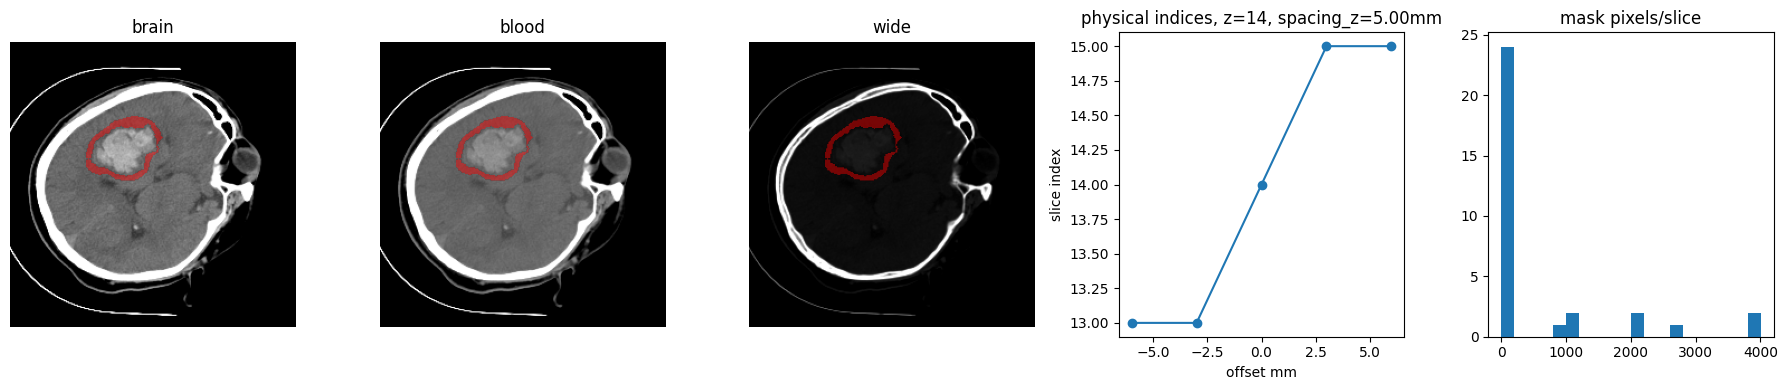

In [7]:
def largest_mask_slice(mask_volume: np.ndarray) -> int:
    if mask_volume.ndim != 3:
        return 0
    per_slice = mask_volume.reshape((-1, mask_volume.shape[2])).sum(axis=0)
    return int(np.argmax(per_slice))


def show_case_windows(row: pd.Series, image_size: int = 256):
    img, spacing, _ = load_nifti(Path(row["img_path"]))
    mask, _, _ = load_nifti(Path(row["mask_path"]))
    z = largest_mask_slice(mask)
    window_stack = make_2d_stack(img, z, image_size=image_size)
    mask_2d = resize_mask(np.asarray(mask[:, :, z]), image_size=image_size)
    indices = physical_neighbor_indices(z, img.shape[2], spacing[2])

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for c, (name, _, _) in enumerate(CFG.windows):
        axes[c].imshow(window_stack[c], cmap="gray")
        axes[c].imshow(np.ma.masked_where(mask_2d == 0, mask_2d), cmap="autumn", alpha=0.45)
        axes[c].set_title(name)
        axes[c].axis("off")
    axes[3].plot(CFG.physical_offsets_mm, indices, marker="o")
    axes[3].set_title(f"physical indices, z={z}, spacing_z={spacing[2]:.2f}mm")
    axes[3].set_xlabel("offset mm")
    axes[3].set_ylabel("slice index")
    axes[4].hist(mask.reshape((-1, mask.shape[2])).sum(axis=0), bins=20)
    axes[4].set_title("mask pixels/slice")
    plt.tight_layout()
    return fig


if len(phe_folds_df) and NIB_AVAILABLE and SCIPY_AVAILABLE:
    sample_row = phe_folds_df.sort_values("mask_volume_ml", ascending=False).iloc[0]
    fig = show_case_windows(sample_row, image_size=CFG.smoke_image_size)
    fig.savefig(FIG_DIR / "sample_phe_windows_physical_stack.png", dpi=160, bbox_inches="tight")
else:
    print("Skip visualization because PHE data, nibabel or scipy is unavailable.")


## 7. PyTorch Dataset cho 2D và 2.5D

Dataset trả về:

- `image`: 3 channels cho 2D hoặc 15 channels cho 2.5D physical-aware.
- `mask`: mask trung tâm.
- `prior`: teacher prior nếu đã sinh, nếu chưa có thì dùng tensor 0 để smoke-test.
- `area_ml`: diện tích mask trung tâm quy đổi ml lát cắt bằng spacing gốc.


In [8]:
if TORCH_AVAILABLE:
    class SliceStackDataset(Dataset):
        def __init__(
            self,
            df: pd.DataFrame,
            mode: str = "2d",
            image_size: int = CFG.image_size,
            positive_only: bool = False,
            max_subjects: Optional[int] = None,
            prior_dir: Optional[Path] = None,
        ):
            self.df = df.copy().reset_index(drop=True)
            if max_subjects is not None:
                self.df = self.df.iloc[:max_subjects].copy()
            self.mode = mode
            self.image_size = int(image_size)
            self.positive_only = positive_only
            self.prior_dir = Path(prior_dir) if prior_dir else None
            self._volume_cache = {}
            self.index = self._build_index()

        def _load_pair(self, row_idx: int):
            if row_idx not in self._volume_cache:
                row = self.df.iloc[row_idx]
                image, spacing, _ = load_nifti(Path(row["img_path"]))
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                self._volume_cache[row_idx] = (image.astype(np.float32), (mask > 0).astype(np.uint8), spacing)
            return self._volume_cache[row_idx]

        def _build_index(self):
            items = []
            for row_idx, row in self.df.iterrows():
                if not Path(row["mask_path"]).exists():
                    continue
                mask, spacing, _ = load_nifti(Path(row["mask_path"]))
                mask = np.asarray(mask) > 0
                n_slices = mask.shape[2]
                if self.positive_only:
                    z_indices = np.where(mask.reshape((-1, n_slices)).sum(axis=0) > 0)[0].tolist()
                    if not z_indices:
                        z_indices = list(range(n_slices))
                else:
                    z_indices = list(range(n_slices))
                items.extend((row_idx, int(z)) for z in z_indices)
            return items

        def __len__(self):
            return len(self.index)

        def _load_prior(self, scan_id: str, z: int):
            if self.prior_dir is None:
                return np.zeros((self.image_size, self.image_size), dtype=np.float32)
            prior_path = self.prior_dir / f"{scan_id}.npz"
            if not prior_path.exists():
                return np.zeros((self.image_size, self.image_size), dtype=np.float32)
            arr = np.load(prior_path)
            prior = arr["prior"]
            if prior.ndim == 3:
                prior = prior[:, :, z]
            return resize_2d(prior.astype(np.float32), self.image_size, order=1)

        def __getitem__(self, idx: int):
            row_idx, z = self.index[idx]
            row = self.df.iloc[row_idx]
            image, mask, spacing = self._load_pair(row_idx)
            if self.mode == "2d":
                x = make_2d_stack(image, z, image_size=self.image_size)
            elif self.mode in {"25d", "2.5d"}:
                x = make_25d_stack(image, z, spacing_z=spacing[2], image_size=self.image_size)
            else:
                raise ValueError(f"Unknown mode: {self.mode}")
            y = resize_mask(mask[:, :, z], image_size=self.image_size)
            prior = self._load_prior(str(row["scan_id"]), z)
            pixel_area_mm2 = float(spacing[0] * spacing[1])
            slice_area_ml = float(y.sum() * pixel_area_mm2 * spacing[2] / 1000.0)
            return {
                "image": torch.from_numpy(x).float(),
                "mask": torch.from_numpy(y[None]).float(),
                "prior": torch.from_numpy(prior[None]).float(),
                "area_ml": torch.tensor([slice_area_ml], dtype=torch.float32),
                "scan_id": str(row["scan_id"]),
                "slice_idx": int(z),
                "spacing": torch.tensor(spacing, dtype=torch.float32),
            }


    if CFG.run_smoke_test and len(train_df):
        smoke_ds = SliceStackDataset(
            train_df,
            mode="25d",
            image_size=CFG.smoke_image_size,
            positive_only=True,
            max_subjects=CFG.max_smoke_subjects,
        )
        sample = smoke_ds[0]
        print({k: (tuple(v.shape) if hasattr(v, "shape") else v) for k, v in sample.items() if k in ["image", "mask", "prior", "area_ml"]})
        print("Smoke dataset slices:", len(smoke_ds))
else:
    print("Torch unavailable. Install torch to enable Dataset/DataLoader and training.")


{'image': (15, 256, 256), 'mask': (1, 256, 256), 'prior': (1, 256, 256), 'area_ml': (1,)}
Smoke dataset slices: 11


## 8. Multi-head U-Net teacher/student

Mô hình đủ minh bạch để tái lập:

- teacher học source ICH để dự đoán hemorrhage mask/prior.
- student học PHE mask, đồng thời học prior alignment, area regression và uncertainty log-variance.
- cùng backbone có thể chạy 2D (`in_channels=3`) hoặc 2.5D physical-aware (`in_channels=15`).


In [9]:
if TORCH_AVAILABLE:
    class DoubleConv(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.SiLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.SiLU(inplace=True),
            )

        def forward(self, x):
            return self.net(x)


    class TinyMultiTaskUNet(nn.Module):
        def __init__(self, in_channels=3, base=32):
            super().__init__()
            self.enc1 = DoubleConv(in_channels, base)
            self.enc2 = DoubleConv(base, base * 2)
            self.enc3 = DoubleConv(base * 2, base * 4)
            self.pool = nn.MaxPool2d(2)
            self.bottleneck = DoubleConv(base * 4, base * 8)
            self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
            self.dec3 = DoubleConv(base * 8, base * 4)
            self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
            self.dec2 = DoubleConv(base * 4, base * 2)
            self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
            self.dec1 = DoubleConv(base * 2, base)
            self.seg_head = nn.Conv2d(base, 1, kernel_size=1)
            self.prior_head = nn.Conv2d(base, 1, kernel_size=1)
            self.log_var_head = nn.Conv2d(base, 1, kernel_size=1)
            self.area_head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(base, 1))

        def forward(self, x):
            e1 = self.enc1(x)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))
            b = self.bottleneck(self.pool(e3))
            d3 = self.up3(b)
            d3 = self.dec3(torch.cat([d3, e3], dim=1))
            d2 = self.up2(d3)
            d2 = self.dec2(torch.cat([d2, e2], dim=1))
            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1, e1], dim=1))
            return {
                "seg_logits": self.seg_head(d1),
                "prior_logits": self.prior_head(d1),
                "log_var": self.log_var_head(d1).clamp(-8.0, 8.0),
                "area_ml": F.softplus(self.area_head(d1)),
            }


    def build_model(mode: str = "2d", base: int = 32):
        in_channels = len(CFG.windows) if mode == "2d" else len(CFG.windows) * len(CFG.physical_offsets_mm)
        return TinyMultiTaskUNet(in_channels=in_channels, base=base)


    if CFG.run_smoke_test:
        model_25d = build_model("25d", base=16).to(DEVICE)
        x = torch.zeros(1, len(CFG.windows) * len(CFG.physical_offsets_mm), CFG.smoke_image_size, CFG.smoke_image_size, device=DEVICE)
        with torch.no_grad():
            out = model_25d(x)
        print({k: tuple(v.shape) for k, v in out.items()})
else:
    print("Torch unavailable. Model definitions skipped.")


{'seg_logits': (1, 1, 256, 256), 'prior_logits': (1, 1, 256, 256), 'log_var': (1, 1, 256, 256), 'area_ml': (1, 1)}


## 9. Loss: DiceFocal + boundary + prior + area + aleatoric uncertainty

Loss bám đúng công thức trong plan. Với teacher source ICH có thể dùng `seg_logits` làm hemorrhage mask. Với student PHE, `prior_logits` được align với soft prior từ teacher.


In [10]:
if TORCH_AVAILABLE:
    def dice_loss_from_logits(logits, targets, eps=1e-6):
        probs = torch.sigmoid(logits)
        dims = tuple(range(1, probs.ndim))
        intersection = (probs * targets).sum(dims)
        union = probs.sum(dims) + targets.sum(dims)
        dice = (2.0 * intersection + eps) / (union + eps)
        return 1.0 - dice.mean()


    def focal_bce_from_logits(logits, targets, alpha=0.25, gamma=2.0):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = targets * p + (1 - targets) * (1 - p)
        alpha_t = targets * alpha + (1 - targets) * (1 - alpha)
        return (alpha_t * (1 - pt).pow(gamma) * bce).mean()


    def gradient_boundary_loss(logits, targets):
        probs = torch.sigmoid(logits)
        pred_dx = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1])
        pred_dy = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :])
        targ_dx = torch.abs(targets[:, :, :, 1:] - targets[:, :, :, :-1])
        targ_dy = torch.abs(targets[:, :, 1:, :] - targets[:, :, :-1, :])
        return F.l1_loss(pred_dx, targ_dx) + F.l1_loss(pred_dy, targ_dy)


    def aleatoric_bce_loss(seg_logits, targets, log_var):
        bce = F.binary_cross_entropy_with_logits(seg_logits, targets, reduction="none")
        precision = torch.exp(-log_var)
        return (precision * bce + log_var).mean()


    def multitask_loss(outputs, batch, weights=None):
        weights = weights or {"seg": 1.0, "bd": 0.1, "prior": 0.2, "area": 0.05, "unc": 0.1}
        y = batch["mask"].to(outputs["seg_logits"].device)
        prior = batch["prior"].to(outputs["seg_logits"].device)
        area = batch["area_ml"].to(outputs["seg_logits"].device)
        seg_loss = dice_loss_from_logits(outputs["seg_logits"], y) + focal_bce_from_logits(outputs["seg_logits"], y)
        bd_loss = gradient_boundary_loss(outputs["seg_logits"], y)
        prior_loss = F.mse_loss(torch.sigmoid(outputs["prior_logits"]), prior)
        area_loss = F.smooth_l1_loss(outputs["area_ml"], area)
        unc_loss = aleatoric_bce_loss(outputs["seg_logits"], y, outputs["log_var"])
        total = (
            weights["seg"] * seg_loss
            + weights["bd"] * bd_loss
            + weights["prior"] * prior_loss
            + weights["area"] * area_loss
            + weights["unc"] * unc_loss
        )
        return total, {
            "loss": float(total.detach().cpu()),
            "seg": float(seg_loss.detach().cpu()),
            "boundary": float(bd_loss.detach().cpu()),
            "prior": float(prior_loss.detach().cpu()),
            "area": float(area_loss.detach().cpu()),
            "unc": float(unc_loss.detach().cpu()),
        }
else:
    print("Torch unavailable. Loss functions skipped.")


## 10. Training loops và curriculum 3 giai đoạn

Curriculum theo plan:

1. **Pretrain teacher** trên Seg-CQ500 + INSTANCE cho binary ICH segmentation.
2. **Adapt teacher** trên PhysioNet nếu đã có DUA và dữ liệu local.
3. **Fine-tune student** trên PHE-SICH với 10/25/50/100% nhãn, dùng soft prior từ teacher.

Các cell train không tự chạy nặng trừ khi bật `CFG.run_heavy_training`.


In [11]:
if TORCH_AVAILABLE:
    def train_one_epoch(model, loader, optimizer, device=DEVICE, scaler=None):
        model.train()
        history = []
        for batch in loader:
            optimizer.zero_grad(set_to_none=True)
            x = batch["image"].to(device)
            if scaler is not None:
                with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                    outputs = model(x)
                    loss, parts = multitask_loss(outputs, batch)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(x)
                loss, parts = multitask_loss(outputs, batch)
                loss.backward()
                optimizer.step()
            history.append(parts)
        return pd.DataFrame(history).mean(numeric_only=True).to_dict() if history else {}


    @torch.no_grad()
    def evaluate_slices(model, loader, threshold=0.5, device=DEVICE):
        model.eval()
        rows = []
        for batch in loader:
            x = batch["image"].to(device)
            y = batch["mask"].to(device)
            out = model(x)
            prob = torch.sigmoid(out["seg_logits"])
            pred = (prob >= threshold).float()
            dims = tuple(range(1, pred.ndim))
            inter = (pred * y).sum(dims)
            union = pred.sum(dims) + y.sum(dims)
            dice = ((2 * inter + 1e-6) / (union + 1e-6)).detach().cpu().numpy()
            rows.extend({"dice": float(v)} for v in dice)
        return pd.DataFrame(rows)


    def fit_model(model, train_loader, val_loader=None, epochs=1, lr=3e-4, ckpt_path=None):
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
        logs = []
        for epoch in range(1, epochs + 1):
            train_metrics = train_one_epoch(model, train_loader, optimizer, scaler=scaler)
            row = {"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()}}
            if val_loader is not None:
                val_metrics = evaluate_slices(model, val_loader)
                row["val_dice"] = float(val_metrics["dice"].mean()) if len(val_metrics) else np.nan
            logs.append(row)
            print(row)
        if ckpt_path:
            torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "logs": logs}, ckpt_path)
        return pd.DataFrame(logs)


source_df = master_df[master_df["task"] == "ich_segmentation"].copy()
physionet_df = master_df[master_df["dataset"] == "PhysioNet_CT_ICH"].copy()

if CFG.run_heavy_training and len(source_df):
    teacher_mode = "25d"
    teacher_train_ds = SliceStackDataset(source_df, mode=teacher_mode, image_size=CFG.image_size, positive_only=False)
    teacher_train_loader = DataLoader(teacher_train_ds, batch_size=8 if teacher_mode != "2d" else 16, shuffle=True, num_workers=0)
    teacher = build_model(teacher_mode, base=32).to(DEVICE)
    teacher_logs = fit_model(
        teacher,
        teacher_train_loader,
        epochs=80,
        lr=3e-4,
        ckpt_path=CHECKPOINT_DIR / f"teacher_source_{teacher_mode}.pt",
    )
    teacher_logs.to_csv(LOG_DIR / f"teacher_source_{teacher_mode}.csv", index=False)
else:
    print("Teacher pretraining skipped. Set CFG.run_heavy_training=True to run.")


Teacher pretraining skipped. Set CFG.run_heavy_training=True to run.


## 11. Sinh soft hemorrhage prior trên PHE-SICH

Prior được sinh từ teacher ICH trên ảnh PHE-SICH. Đây là khác biệt chính với hướng pseudo-label IPH từ edema mask: prior đến từ external ICH knowledge, không suy ngược từ nhãn PHE.


In [12]:
if TORCH_AVAILABLE:
    @torch.no_grad()
    def predict_prior_volume(model, row: pd.Series, mode: str = "25d", image_size: int = CFG.image_size, device=DEVICE):
        model.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        priors = []
        for z in range(image.shape[2]):
            if mode == "2d":
                x = make_2d_stack(image, z, image_size=image_size)
            else:
                x = make_25d_stack(image, z, spacing_z=spacing[2], image_size=image_size)
            xb = torch.from_numpy(x[None]).float().to(device)
            out = model(xb)
            prior = torch.sigmoid(out["seg_logits"])[0, 0].detach().cpu().numpy()
            prior = resize_2d(prior, image.shape[0], order=1)
            if prior.shape != image.shape[:2]:
                prior = ndimage.zoom(prior, (image.shape[0] / prior.shape[0], image.shape[1] / prior.shape[1]), order=1)
            priors.append(prior.astype(np.float16))
        return np.stack(priors, axis=2)


    def generate_phe_priors_from_checkpoint(ckpt_path: Path, mode: str = "25d", max_cases: Optional[int] = None):
        model = build_model(mode, base=32).to(DEVICE)
        state = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(state["model"])
        rows = phe_folds_df.iloc[:max_cases] if max_cases else phe_folds_df
        for _, row in rows.iterrows():
            out_path = PRIOR_DIR / f"{row['scan_id']}.npz"
            if out_path.exists():
                continue
            prior = predict_prior_volume(model, row, mode=mode, image_size=CFG.image_size)
            np.savez_compressed(out_path, prior=prior)
            print("saved", out_path)
else:
    print("Torch unavailable. Prior generation helpers skipped.")


teacher_ckpt = CHECKPOINT_DIR / "teacher_source_25d.pt"
if TORCH_AVAILABLE and CFG.run_heavy_training and teacher_ckpt.exists():
    generate_phe_priors_from_checkpoint(teacher_ckpt, mode="25d")
elif TORCH_AVAILABLE:
    print("Prior generation skipped. Train/load a teacher checkpoint first.")


Prior generation skipped. Train/load a teacher checkpoint first.


## 12. Fine-tune PHE student ở 10/25/50/100% nhãn

Ở 10% và 25%, nên freeze các stage đầu của encoder vài epoch đầu nếu dùng backbone lớn. Với U-Net nhẹ trong notebook, freeze được để thành hook cấu hình, nhưng mặc định không bật.


In [13]:
if TORCH_AVAILABLE:
    def freeze_encoder_stem(model, freeze: bool = True):
        for module in [model.enc1, model.enc2]:
            for p in module.parameters():
                p.requires_grad = not freeze


    def run_student_finetune(mode: str = "25d", label_fraction: float = 1.0, epochs: int = 60):
        train_subset = low_label_subsets[label_fraction]
        train_ds = SliceStackDataset(train_subset, mode=mode, image_size=CFG.image_size, positive_only=False, prior_dir=PRIOR_DIR)
        val_ds = SliceStackDataset(val_df, mode=mode, image_size=CFG.image_size, positive_only=False, prior_dir=PRIOR_DIR)
        batch_size = 8 if mode != "2d" else 16
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
        model = build_model(mode, base=32).to(DEVICE)
        if label_fraction in (0.10, 0.25):
            freeze_encoder_stem(model, True)
        ckpt = CHECKPOINT_DIR / f"student_phe_{mode}_fold{CFG.outer_fold}_{int(label_fraction * 100)}pct.pt"
        logs = fit_model(model, train_loader, val_loader, epochs=epochs, lr=1e-4, ckpt_path=ckpt)
        logs.to_csv(LOG_DIR / f"student_phe_{mode}_fold{CFG.outer_fold}_{int(label_fraction * 100)}pct.csv", index=False)
        return model, logs
else:
    print("Torch unavailable. Student fine-tuning helpers skipped.")


if TORCH_AVAILABLE and CFG.run_heavy_training:
    student_runs = {}
    for mode in ["2d", "25d"]:
        for frac in CFG.label_fractions:
            student_runs[(mode, frac)] = run_student_finetune(mode=mode, label_fraction=frac, epochs=60)
elif TORCH_AVAILABLE:
    print("Student fine-tuning skipped. Set CFG.run_heavy_training=True to run.")


Student fine-tuning skipped. Set CFG.run_heavy_training=True to run.


## 13. Đánh giá volume-level, calibration và uncertainty

Mọi metric chính được tính ở mức subject/volume, không chỉ slice. Các hàm dưới đây hỗ trợ Dice, IoU, HD95, ASSD, NSD, volume MAE/RMSE, ECE, Brier và bootstrap CI.


In [14]:
def binary_dice(pred: np.ndarray, target: np.ndarray, eps: float = 1e-6) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    return float((2 * np.logical_and(pred, target).sum() + eps) / (pred.sum() + target.sum() + eps))


def binary_iou(pred: np.ndarray, target: np.ndarray, eps: float = 1e-6) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    inter = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()
    return float((inter + eps) / (union + eps))


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float((mask > 0).sum() * np.prod(spacing) / 1000.0)


def surface_distances(pred: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float]):
    if not SCIPY_AVAILABLE:
        return np.array([]), np.array([])
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 or target.sum() == 0:
        return np.array([np.inf]), np.array([np.inf])
    structure = ndimage.generate_binary_structure(3, 1)
    pred_surface = np.logical_xor(pred, ndimage.binary_erosion(pred, structure=structure, border_value=0))
    target_surface = np.logical_xor(target, ndimage.binary_erosion(target, structure=structure, border_value=0))
    dt_pred = ndimage.distance_transform_edt(~pred_surface, sampling=spacing)
    dt_target = ndimage.distance_transform_edt(~target_surface, sampling=spacing)
    return dt_target[pred_surface], dt_pred[target_surface]


def hd95_assd_nsd(pred: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float], nsd_tolerance_mm: float = 2.0):
    d1, d2 = surface_distances(pred, target, spacing)
    d = np.concatenate([d1, d2])
    finite = d[np.isfinite(d)]
    if len(finite) == 0:
        return {"hd95": np.inf, "assd": np.inf, "nsd": 0.0}
    return {
        "hd95": float(np.percentile(finite, 95)),
        "assd": float(finite.mean()),
        "nsd": float((finite <= nsd_tolerance_mm).mean()),
    }


def expected_calibration_error(probs: np.ndarray, targets: np.ndarray, n_bins: int = 15) -> float:
    probs = probs.reshape(-1).astype(np.float32)
    targets = targets.reshape(-1).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (probs >= lo) & (probs < hi if hi < 1.0 else probs <= hi)
        if not mask.any():
            continue
        conf = probs[mask].mean()
        acc = targets[mask].mean()
        ece += mask.mean() * abs(conf - acc)
    return float(ece)


def brier_score(probs: np.ndarray, targets: np.ndarray) -> float:
    return float(np.mean((probs.astype(np.float32) - targets.astype(np.float32)) ** 2))


def bootstrap_ci(values: Sequence[float], n_boot: int = 2000, alpha: float = 0.05, seed: int = CFG.seed):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return {"mean": np.nan, "lo": np.nan, "hi": np.nan}
    rng = np.random.default_rng(seed)
    boots = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    return {
        "mean": float(values.mean()),
        "lo": float(np.percentile(boots, 100 * alpha / 2)),
        "hi": float(np.percentile(boots, 100 * (1 - alpha / 2))),
    }


def evaluate_probability_volume(prob: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float], threshold: float = 0.5) -> Dict:
    pred = prob >= threshold
    target_bin = target > 0
    pred_ml = volume_ml(pred, spacing)
    target_ml = volume_ml(target_bin, spacing)
    surface = hd95_assd_nsd(pred, target_bin, spacing)
    return {
        "dice": binary_dice(pred, target_bin),
        "iou": binary_iou(pred, target_bin),
        "pred_volume_ml": pred_ml,
        "target_volume_ml": target_ml,
        "volume_abs_error_ml": abs(pred_ml - target_ml),
        "ece": expected_calibration_error(prob, target_bin),
        "brier": brier_score(prob, target_bin),
        **surface,
    }


In [15]:
if TORCH_AVAILABLE:
    @torch.no_grad()
    def predict_phe_probability_volume(model, row: pd.Series, mode: str = "25d", image_size: int = CFG.image_size, device=DEVICE):
        model.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        probs = []
        for z in range(image.shape[2]):
            if mode == "2d":
                x = make_2d_stack(image, z, image_size=image_size)
            else:
                x = make_25d_stack(image, z, spacing_z=spacing[2], image_size=image_size)
            xb = torch.from_numpy(x[None]).float().to(device)
            out = model(xb)
            prob = torch.sigmoid(out["seg_logits"])[0, 0].detach().cpu().numpy()
            prob = resize_2d(prob, image.shape[0], order=1)
            if prob.shape != image.shape[:2]:
                prob = ndimage.zoom(prob, (image.shape[0] / prob.shape[0], image.shape[1] / prob.shape[1]), order=1)
            probs.append(prob.astype(np.float32))
        return np.stack(probs, axis=2), spacing


    def evaluate_checkpoint_volume_level(ckpt_path: Path, test_subjects: pd.DataFrame, mode: str = "25d", threshold: float = 0.5):
        model = build_model(mode, base=32).to(DEVICE)
        state = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(state["model"])
        rows = []
        for _, row in test_subjects.iterrows():
            prob, spacing = predict_phe_probability_volume(model, row, mode=mode)
            target, _, _ = load_nifti(Path(row["mask_path"]))
            metrics = evaluate_probability_volume(prob, target, spacing, threshold=threshold)
            rows.append({"scan_id": row["scan_id"], **metrics})
        return pd.DataFrame(rows)
else:
    print("Torch unavailable. Checkpoint evaluation helpers skipped.")


student_ckpt = CHECKPOINT_DIR / f"student_phe_25d_fold{CFG.outer_fold}_100pct.pt"
if TORCH_AVAILABLE and CFG.run_heavy_training and student_ckpt.exists():
    volume_eval_df = evaluate_checkpoint_volume_level(student_ckpt, test_df, mode="25d")
    volume_eval_df.to_csv(TABLE_DIR / "volume_eval_student_25d_100pct.csv", index=False)
    display(volume_eval_df.describe())
    display(pd.DataFrame({m: bootstrap_ci(volume_eval_df[m]) for m in ["dice", "hd95", "nsd", "volume_abs_error_ml"]}).T)
elif TORCH_AVAILABLE:
    print("Volume evaluation skipped until a student checkpoint is available.")


Volume evaluation skipped until a student checkpoint is available.


## 14. Experiment matrix và ablation registry

Đây là danh sách chạy có kiểm soát, tránh nổ compute. Baseline đầy đủ chỉ cần ở 100% nhãn; low-label tập trung vào nnU-Net 2D, một transformer baseline tốt nhất, Proposed 2D và Proposed 2.5D.


In [16]:
experiment_matrix = pd.DataFrame([
    {"block": "baseline_100pct", "model": "U-Net", "mode": "2d", "label_pct": 100, "required": True},
    {"block": "baseline_100pct", "model": "Attention U-Net", "mode": "2d", "label_pct": 100, "required": True},
    {"block": "baseline_100pct", "model": "nnU-Net", "mode": "2d", "label_pct": 100, "required": True},
    {"block": "baseline_100pct", "model": "nnU-Net multi-channel", "mode": "25d_index_or_channel", "label_pct": 100, "required": True},
    {"block": "baseline_100pct", "model": "TransUNet/Swin-like", "mode": "2d", "label_pct": 100, "required": True},
    {"block": "baseline_100pct", "model": "Proposed teacher-student", "mode": "2d", "label_pct": 100, "required": True},
    {"block": "baseline_100pct", "model": "Proposed teacher-student", "mode": "25d_physical", "label_pct": 100, "required": True},
])

for pct in [10, 25, 50, 100]:
    for model, mode in [
        ("nnU-Net", "2d"),
        ("Best transformer baseline", "2d"),
        ("Proposed teacher-student", "2d"),
        ("Proposed teacher-student", "25d_physical"),
    ]:
        experiment_matrix.loc[len(experiment_matrix)] = {
            "block": "label_efficiency",
            "model": model,
            "mode": mode,
            "label_pct": pct,
            "required": True,
        }

transfer_ablation = pd.DataFrame([
    {"ablation": "no_pretrain", "source": "none", "question": "Does external ICH pretraining matter?"},
    {"ablation": "seg_cq500_only", "source": "Seg-CQ500", "question": "How much does clean 3D ICH mask source help?"},
    {"ablation": "physionet_only", "source": "PhysioNet CT-ICH", "question": "How much do thick slices and negatives help?"},
    {"ablation": "seg_plus_physionet", "source": "Seg-CQ500 + PhysioNet", "question": "Core public track without INSTANCE."},
    {"ablation": "plus_instance", "source": "Seg-CQ500 + PhysioNet + INSTANCE", "question": "Optional extension if access is valid."},
])

component_ablation = pd.DataFrame([
    {"ablation": "2d_vs_25d_index_vs_25d_physical", "primary_metric": "Dice, HD95, volume MAE"},
    {"ablation": "single_window_vs_three_window", "primary_metric": "Dice, false positives near skull"},
    {"ablation": "no_prior_head_vs_prior_distillation", "primary_metric": "low-label Dice"},
    {"ablation": "no_area_head_vs_area_head", "primary_metric": "volume MAE/RMSE"},
    {"ablation": "no_uncertainty_vs_uncertainty_scaling", "primary_metric": "ECE, Brier"},
    {"ablation": "leave_one_source_out", "primary_metric": "source contribution"},
    {"ablation": "freeze_schedule", "primary_metric": "10/25% stability"},
])

experiment_matrix.to_csv(TABLE_DIR / "experiment_matrix.csv", index=False)
transfer_ablation.to_csv(TABLE_DIR / "transfer_ablation.csv", index=False)
component_ablation.to_csv(TABLE_DIR / "component_ablation.csv", index=False)

display(experiment_matrix.head(20))
display(transfer_ablation)
display(component_ablation)


,block,model,mode,label_pct,required
0,baseline_100pct,U-Net,2d,100,True
1,baseline_100pct,Attention U-Net,2d,100,True
2,baseline_100pct,nnU-Net,2d,100,True
3,baseline_100pct,nnU-Net multi-channel,25d_index_or_channel,100,True
4,baseline_100pct,TransUNet/Swin-like,2d,100,True
5,baseline_100pct,Proposed teacher-student,2d,100,True
6,baseline_100pct,Proposed teacher-student,25d_physical,100,True
7,label_efficiency,nnU-Net,2d,10,True
8,label_efficiency,Best transformer baseline,2d,10,True
9,label_efficiency,Proposed teacher-student,2d,10,True


,ablation,source,question
0,no_pretrain,none,Does external ICH pretraining matter?
1,seg_cq500_only,Seg-CQ500,How much does clean 3D ICH mask source help?
2,physionet_only,PhysioNet CT-ICH,How much do thick slices and negatives help?
3,seg_plus_physionet,Seg-CQ500 + PhysioNet,Core public track without INSTANCE.
4,plus_instance,Seg-CQ500 + PhysioNet + INSTANCE,Optional extension if access is valid.


,ablation,primary_metric
0,2d_vs_25d_index_vs_25d_physical,"Dice, HD95, volume MAE"
1,single_window_vs_three_window,"Dice, false positives near skull"
2,no_prior_head_vs_prior_distillation,low-label Dice
3,no_area_head_vs_area_head,volume MAE/RMSE
4,no_uncertainty_vs_uncertainty_scaling,"ECE, Brier"
5,leave_one_source_out,source contribution
6,freeze_schedule,10/25% stability


## 15. Reproducibility pack

Các artifact tối thiểu trước khi nộp bài:

- `subjects_master.csv`, `folds_phe_sich_v1.csv`, low-label subset CSV.
- Config đầy đủ, seed, package versions.
- Logs/checkpoint theo fold.
- Bảng metric patient-level kèm bootstrap CI.
- Data card/model card và license notes, đặc biệt với PhysioNet DUA.


In [17]:
def package_versions() -> Dict[str, str]:
    versions = {
        "python": ".".join(map(str, os.sys.version_info[:3])),
        "numpy": np.__version__,
        "pandas": pd.__version__,
    }
    if NIB_AVAILABLE:
        versions["nibabel"] = nib.__version__
    if SCIPY_AVAILABLE:
        import scipy
        versions["scipy"] = scipy.__version__
    if TORCH_AVAILABLE:
        versions["torch"] = torch.__version__
    return versions


run_metadata = {
    "config": {
        **asdict(CFG),
        "project_root": str(PROJECT_ROOT),
        "output_root": str(OUTPUT_ROOT),
        "windows": list(CFG.windows),
        "physical_offsets_mm": list(CFG.physical_offsets_mm),
    },
    "package_versions": package_versions(),
    "datasets": audit_df.to_dict(orient="records"),
    "manifest_path": str(master_path),
    "fold_path": str(fold_path),
    "research_constraints": [
        "No RSNA/BHSD in core track",
        "No pseudo-IPH labels inferred from PHE masks",
        "Patient-level splits only",
        "Report volume-level metrics with uncertainty/calibration",
    ],
}

with open(LOG_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, ensure_ascii=False, indent=2, default=str)

data_card = f"""
# Data Card - Q1 PHE/ICH Prior Transfer

Target dataset:
- PHE-SICH-CT-IDS SubdatasetA NIfTI, role: target PHE segmentation.

Source datasets:
- Seg-CQ500, role: source ICH segmentation.
- INSTANCE 2022 train labels, role: optional source extension, verify challenge terms.
- PhysioNet CT-ICH, role: optional restricted source after DUA.

Split policy:
- Patient/scan-level 5-fold CV.
- Low-label subsets are sampled from train subjects only.

Core exclusions:
- RSNA/BHSD are not part of the core paper track.
- No pseudo-IPH labels are inferred from PHE edema masks.
"""
(LOG_DIR / "DATA_CARD.md").write_text(data_card, encoding="utf-8")

model_card = """
# Model Card - Teacher Student PHE Segmentation

Architecture:
- Tiny multi-head U-Net reference implementation.
- Teacher: binary ICH segmentation on source datasets.
- Student: PHE segmentation with prior alignment, area regression and uncertainty log-variance.

Inputs:
- 2D: 3 CT windows.
- 2.5D: 5 physical offsets x 3 CT windows.

Outputs:
- PHE probability map.
- Prior alignment map.
- Slice area prediction.
- Uncertainty log-variance map.

Evaluation:
- Patient-level Dice, IoU, HD95, ASSD, NSD.
- Volume MAE/RMSE/correlation.
- Pixel-wise ECE, Brier score and calibration analysis.
"""
(LOG_DIR / "MODEL_CARD.md").write_text(model_card, encoding="utf-8")

print("Saved reproducibility pack to:", LOG_DIR)


Saved reproducibility pack to: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_q1_prior_transfer\logs


## 16. Next actions

1. Chạy các cell audit/manifest để xác nhận dữ liệu local.
2. Nếu có PhysioNet, đặt dữ liệu vào `PhysioNet_CT_ICH/` hoặc sửa `PHYSIONET_ROOT`.
3. Bật `CFG.run_heavy_training=True` khi muốn train thật.
4. Chạy source teacher trước, sinh prior trên PHE, rồi fine-tune student low-label.
5. Chốt bảng volume-level metrics và bootstrap CI cho paper.

Notebook này cố tình giữ mô hình reference gọn. Khi chuyển sang paper thật, thay backbone trong `build_model` bằng ConvNeXt/ResNet hoặc nnU-Net baseline, nhưng giữ nguyên manifest, split, 2.5D physical stack và evaluation protocol.
